In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Przypisanie danych tytanica do ramki danych df (data frame)

In [2]:
df = sns.load_dataset('titanic')

# Wstępna analiza danych

In [3]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


# Obliczenie ciekawych informacji o danych cechach numerycznych

In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Podliczenie liczby braków w danych kolumnach, cechach

In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# Typy przechowywanych wartości

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [10]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

# Kolumny do usunięcia
# 1. Kolumna deck ma zbyt wiele braków (więcej niż 50%) przez co jej uzupełnienie różnymi metodami będzie nieefektywne.
# 2. Kolumna embark_town jest powieleniem kolumny embarked z czego jedna kolumna jest zapisana pełną nazwą, a druga pierwszą literą. Można przed uzunięciem wyświetlić pełne nazwy poglądowo.
# 3. Kolumna survived oraz alive reprezentują tą samą cechę, więc jedną można usunąć. Kolumna zawiera wartości 0 lub 1, zaś alive zawiera zmienne bool. Wartości 0 1 będą potrzebne do konstrukcji modelu, więc lepiej usunąć kolumnę z wartościami typu bool, bo zmienne modelu przyjmują wartości 0 1 w regresji.
# 4. Kolumna who reprezentuje te same wartości co połączone kolumny sex + age, więc nie jest potrzebne.
# 5. Kolumna adult_male zawiera cechę, która może zostać łatwo ustalona dzięki kolumnie age, więc nie jest potrzebna.
# 6. Kolumna class reprezentuje tą samą wartość co kolumna pclass. Kolumna class ma wartości w formie słownej (First, Second, Third), a pclass w formie numerycznej (0, 1, 2) - ta forma jest wygodniejsza do używania.
# 7. Kolumna alone to kolumna, która jest pochodną kolumn sibsp i parch.

In [11]:
df['embark_town'].unique()

array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)

In [12]:
df.drop(columns=['deck', 'embark_town', 'alive', 'who', 'adult_male', 'class', 'alone'], inplace=True)

In [13]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [14]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

# Uzupełnienie brakujących wartości w kolumnie age za pomocą mediany. Mediana jest liczona ze względu na cechy pclass - klasa miejsca dla pasażera według kupionego biletu oraz cechę sex - czyli płeć pasażera.

In [15]:
df['age'] = df['age'].fillna(df.groupby(['pclass', 'sex'])['age'].transform('median'))

In [16]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    2
dtype: int64

# W kolumnie embarked brakuje tylko dwóch wartości, więc można uzupełnić brakujące miejsca najczęściej występującą wartością.

In [17]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [18]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

# Zmiana kolumny sex z wartości znakowej na numeryczną ze względu łatwiejszego późniejszego użycia.

In [19]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

In [20]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S
887,1,1,0,19.0,0,0,30.0000,S
888,0,3,0,21.5,1,2,23.4500,S
889,1,1,1,26.0,0,0,30.0000,C


# Użycie metody one-hot encoding, aby zapobiec współliniowości, zapobiec interpretacji, że jakaś cecha jest ważniejsza od drugiej w przypadku, gdzie wartości liczbowe nie oznaczają faktycznej wartości, a po prostu reprezentują cechę nienumeryczną.

In [21]:
df = pd.get_dummies(df, columns=['embarked'], prefix='emb', drop_first=True)

In [22]:
df

,survived,pclass,sex,age,sibsp,parch,fare,emb_Q,emb_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,False,True
887,1,1,0,19.0,0,0,30.0000,False,True
888,0,3,0,21.5,1,2,23.4500,False,True
889,1,1,1,26.0,0,0,30.0000,False,False


# Podział na X i y do treningu modelu. W X zawarte są wszystkie cechy na podstawie, których model ma określić wynik (czy ktoś przeżył lub nie - survived), a y zawiera wynik poprawny jaki model powinien wskazać, czyli wartość survived.

In [23]:
X = df.drop('survived', axis=1)
y = df['survived']

# Podział danych na część do treningu: train (80%) - wartości na których model ma się uczyć i wyciągać wnioski oraz test (20%) - wartości na których model ma zostać przetestowany oraz określenie jego skuteczności. Model nie może uczyć się na danych testowych, aby sprawdzić czy wartości z bazy danych, ale na których model się nie uczył odgadnie poprawnie oraz z jakim prawdopodobieństwe, - określi skuteczność modelu na podstawie odgadniętych poprawnych przypadków.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X_train, y_train

(     pclass  sex   age  sibsp  parch      fare  emb_Q  emb_S
 331       1    1  45.5      0      0   28.5000  False   True
 733       2    1  23.0      0      0   13.0000  False   True
 382       3    1  32.0      0      0    7.9250  False   True
 704       3    1  26.0      1      0    7.8542  False   True
 813       3    0   6.0      4      2   31.2750  False   True
 ..      ...  ...   ...    ...    ...       ...    ...    ...
 106       3    0  21.0      0      0    7.6500  False   True
 270       1    1  40.0      0      0   31.0000  False   True
 860       3    1  41.0      2      0   14.1083  False   True
 435       1    0  14.0      1      2  120.0000  False   True
 102       1    1  21.0      0      1   77.2875  False   True
 
 [712 rows x 8 columns],
 331    0
 733    0
 382    0
 704    0
 813    0
       ..
 106    1
 270    0
 860    0
 435    1
 102    0
 Name: survived, Length: 712, dtype: int64)

# Standaryzacja wartości numerycznych, aby cechy (kolumny) z większymi wartościami nie dominowały w treningu modelu i nie sugerowały, że cechy z mniejszymi wartościami są mniej ważne.

In [26]:
columns_to_standardize = ['pclass', 'age', 'sibsp', 'parch', 'fare']
scaler = StandardScaler()
X_train[columns_to_standardize] = scaler.fit_transform(X_train[columns_to_standardize])
X_test[columns_to_standardize] = scaler.transform(X_test[columns_to_standardize])

In [27]:
X_train, X_test

(       pclass  sex       age     sibsp     parch      fare  emb_Q  emb_S
 331 -1.614136    1  1.249288 -0.470722 -0.479342 -0.078684  False   True
 733 -0.400551    1 -0.445751 -0.470722 -0.479342 -0.377145  False   True
 382  0.813034    1  0.232265 -0.470722 -0.479342 -0.474867  False   True
 704  0.813034    1 -0.219746  0.379923 -0.479342 -0.476230  False   True
 813  0.813034    0 -1.726446  2.931860  2.048742 -0.025249  False   True
 ..        ...  ...       ...       ...       ...       ...    ...    ...
 106  0.813034    0 -0.596421 -0.470722 -0.479342 -0.480162  False   True
 270 -1.614136    1  0.834945 -0.470722 -0.479342 -0.030545  False   True
 860  0.813034    1  0.910280  1.230569 -0.479342 -0.355804  False   True
 435 -1.614136    0 -1.123766  0.379923  2.048742  1.683201  False   True
 102 -1.614136    1 -0.596421 -0.470722  0.784700  0.860748  False   True
 
 [712 rows x 8 columns],
        pclass  sex       age     sibsp     parch      fare  emb_Q  emb_S
 709  0.813

# Trening modelu, z maksymalną ilością iteracji 1000, czyli model przejdzie 1000 razy po wszystkich danych maksymalnie, aby nauczyć się rozpoznawać wyniki, a zatrzyma się wcześniej, gdy dalszy trening będzie bardziej szkodził w skutecznym rozpoznawaniu wyników niż pomagał.

In [28]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Dokładność (accuracy) pokazuje procent poprawnych rozpoznanych przypadków. Macierz pomyłek pokazuje w jakich ilościach model poprawnie rozpoznał wartości 0 lub 1 (nie przeżył lub przeżył) - survived. TN (True Negative) = 92; FP (False Positive) = 13; FN (False Negative) = 19; TP (True Positive) = 55. Model poprawnie rozpoznał osoby, które nie przeżyją (TN = 92) oraz przeżyją (TP = 55), zaś źle rozpoznał osoby, które przeżyją (FP = 13) oraz nie przeżyją (FN = 19).

In [29]:
y_pred = model.predict(X_test)

print('Dokładność (Accuracy Score):', accuracy_score(y_test, y_pred))
print('Macierz pomyłek (Confusion Matrix):', confusion_matrix(y_test, y_pred))
print('Raport', classification_report(y_test, y_pred))

Dokładność (Accuracy Score): 0.8212290502793296
Macierz pomyłek (Confusion Matrix): [[92 13]
 [19 55]]
Raport               precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



# Graficzne przedstawienie macierzy pomyłek

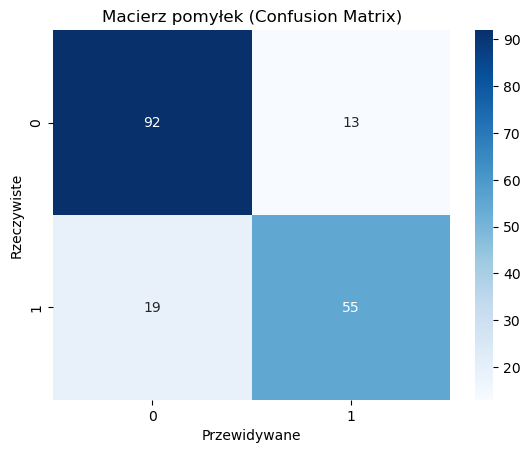

In [30]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Macierz pomyłek (Confusion Matrix)')
plt.xlabel('Przewidywane')
plt.ylabel('Rzeczywiste')
plt.show()